## importing required packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
#from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## reading the dataset

In [ ]:
house_cost = pd.read_csv('C:\\UsersOneDrive - REVA University\\Desktop\\ML project\\apartment_cost_list.csv')

In [ ]:
house_cost.head()

,Job #,Borough,House #,Street Name,Block,Lot,Bin #,Job Type,Community - Board,Curb Cut,Fully Permitted,Initial Cost,Proposed Zoning Sqft,Horizontal Enlrgmt,Vertical Enlrgmt,Enlargement SQ Footage,Zoning Dist1,Job Description
0,123768976,MANHATTAN,1598,2ND AVENUE,1545,49,1049907,A2,108,NaN,NaN,$65000.00,0,NaN,NaN,0,C1-9,INTERIOR RENOVATION TO COMBINE APARTMENT 2E AN...
1,140922893,MANHATTAN,160,E 89 ST,1517,43,1048094,A2,108,NaN,07/14/2020,$85000.00,0,NaN,NaN,0,R8B,HEREBY FILING APPLICATION FOR THE INTERIOR REN...
2,301773579,BROOKLYN,65,GATES AVENUE,1962,86,3056039,A1,302,NaN,05/23/2007,$60000.00,0,NaN,NaN,0,R6,Change existing four story and basement brick ...
3,301976057,BROOKLYN,1401,OCEAN AVENUE,7584,35,3206621,A2,314,NaN,02/28/2006,$75000.00,0,NaN,NaN,0,NaN,COMBINING OF APARTMENT 4A &amp; 4L.NO CHANGEIN...
4,301989276,BROOKLYN,154,NOBLE STREET,2573,10,3065099,A1,301,NaN,09/29/2006,$40000.00,0,NaN,NaN,0,C4-3,New C of O for existing building. New duplex a...


In [ ]:
house_cost.shape

(19613, 18)

In [ ]:
house_cost.isnull().sum()

Job #                         0
Borough                       0
House #                       0
Street Name                   0
Block                         0
Lot                           0
Bin #                         0
Job Type                      0
Community - Board             0
Curb Cut                  19597
Fully Permitted            3988
Initial Cost                  0
Proposed Zoning Sqft          0
Horizontal Enlrgmt        19450
Vertical Enlrgmt          19371
Enlargement SQ Footage        0
Zoning Dist1               2096
Job Description               0
dtype: int64

In [ ]:
# Initialize the StandardScaler object
scaler = StandardScaler()

# Select the numerical features to be scaled
numerical_features = ['Bin #', 'Initial Cost']

# Fit the scaler to the selected features
scaler.fit(house_cost[numerical_features])

# Transform the selected features using the scaler
scaled_features = scaler.transform(house_cost[numerical_features])

# Replace the original features with the scaled features in the DataFrame
house_cost[numerical_features] = scaled_features

In [ ]:
house_cost.head(3)

,Job #,Borough,House #,Street Name,Block,Lot,Bin #,Job Type,Community - Board,Curb Cut,Fully Permitted,Initial Cost,Proposed Zoning Sqft,Horizontal Enlrgmt,Vertical Enlrgmt,Enlargement SQ Footage,Zoning Dist1,Job Description
0,123768976,MANHATTAN,1598,2ND AVENUE,1545,49,-0.489774,A2,108,NaN,NaN,0.208263,0,NaN,NaN,0,C1-9,INTERIOR RENOVATION TO COMBINE APARTMENT 2E AN...
1,140922893,MANHATTAN,160,E 89 ST,1517,43,-0.491719,A2,108,NaN,07/14/2020,0.957702,0,NaN,NaN,0,R8B,HEREBY FILING APPLICATION FOR THE INTERIOR REN...
2,301773579,BROOKLYN,65,GATES AVENUE,1962,86,1.662785,A1,302,NaN,05/23/2007,0.020904,0,NaN,NaN,0,R6,Change existing four story and basement brick ...


In [ ]:
##house_cost['Initial Cost'] = house_cost['Initial Cost'].replace({'\$': '', ',': ''}, regex=True)
##house_cost['Initial Cost'] = house_cost['Initial Cost'].astype(float)
##print(house_cost)


## ***Checking the shape of DataFrame***

In [ ]:
print('Number of rows are',house_cost.shape[0], 'and number of columns are ',house_cost.shape[1])

Number of rows are 19613 and number of columns are  18


In [ ]:
df2 = house_cost.drop(['Zoning Dist1','Community - Board','Fully Permitted','Block','Curb Cut','Job Type','House #','Job #','Bin #','Horizontal Enlrgmt','Vertical Enlrgmt','Street Name','Job Description'],axis='columns')
df2.shape
df2.head()

,Borough,Lot,Initial Cost,Proposed Zoning Sqft,Enlargement SQ Footage
0,MANHATTAN,49,0.208263,0,0
1,MANHATTAN,43,0.957702,0,0
2,BROOKLYN,86,0.020904,0,0
3,BROOKLYN,35,0.582983,0,0
4,BROOKLYN,10,-0.728536,0,0


## ***Checking for null values***

In [ ]:
house_cost.isnull().sum()

Job #                         0
Borough                       0
House #                       0
Street Name                   0
Block                         0
Lot                           0
Bin #                         0
Job Type                      0
Community - Board             0
Curb Cut                  19597
Fully Permitted            3988
Initial Cost                  0
Proposed Zoning Sqft          0
Horizontal Enlrgmt        19450
Vertical Enlrgmt          19371
Enlargement SQ Footage        0
Zoning Dist1               2096
Job Description               0
dtype: int64

In [ ]:
df3 = df2.dropna()
df3.isnull().sum()

Borough                   0
Lot                       0
Initial Cost              0
Proposed Zoning Sqft      0
Enlargement SQ Footage    0
dtype: int64

In [ ]:
df3.shape

(19613, 5)

In [ ]:
df2.Borough.unique()

array(['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND'],
      dtype=object)

In [ ]:
len(df2.Borough.unique())

5

In [ ]:
dummies = pd.get_dummies(df2.Borough)
dummies.head(3)

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
0,0,0,1,0,0
1,0,0,1,0,0
2,0,1,0,0,0


In [ ]:
df4 = pd.concat([df2,dummies],axis='columns')
df4.head(4)

,Borough,Lot,Initial Cost,Proposed Zoning Sqft,Enlargement SQ Footage,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
0,MANHATTAN,49,0.208263,0,0,0,0,1,0,0
1,MANHATTAN,43,0.957702,0,0,0,0,1,0,0
2,BROOKLYN,86,0.020904,0,0,0,1,0,0,0
3,BROOKLYN,35,0.582983,0,0,0,1,0,0,0


In [ ]:
df5 = df4.drop('Borough',axis='columns')
df5.head(2)

,Lot,Initial Cost,Proposed Zoning Sqft,Enlargement SQ Footage,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
0,49,0.208263,0,0,0,0,1,0,0
1,43,0.957702,0,0,0,0,1,0,0


In [ ]:
df5.shape

(19613, 9)

## ***Checking statistical data***

In [ ]:
df5.describe()

,Lot,Initial Cost,Proposed Zoning Sqft,Enlargement SQ Footage,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
count,19613.000000,1.961300e+04,19613.000000,19613.000000,19613.000000,19613.000000,19613.000000,19613.000000,19613.000000
mean,1261.811197,-7.930551e-17,719.625809,18.639219,0.029878,0.143578,0.782185,0.042421,0.001937
std,2764.626109,1.000025e+00,10859.926278,303.278381,0.170255,0.350670,0.412771,0.201552,0.043975
min,0.000000,-7.285356e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,-5.411758e-01,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,36.000000,-9.151235e-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,66.000000,3.956231e-01,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,9007.000000,1.613384e+01,724475.000000,29687.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## ***Computing the correlation matrix***

In [ ]:
df5.corr()

,Lot,Initial Cost,Proposed Zoning Sqft,Enlargement SQ Footage,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
Lot,1.000000,0.017577,-0.010634,-0.021025,-0.067094,-0.117964,0.165517,-0.072903,-0.019036
Initial Cost,0.017577,1.000000,-0.004520,0.000681,0.014150,0.004914,-0.006351,-0.008284,0.003615
Proposed Zoning Sqft,-0.010634,-0.004520,1.000000,0.010333,0.024158,0.006352,-0.060476,0.084735,0.035102
Enlargement SQ Footage,-0.021025,0.000681,0.010333,1.000000,-0.005429,0.035426,-0.054400,0.051670,0.012325
BRONX,-0.067094,0.014150,0.024158,-0.005429,1.000000,-0.071856,-0.332564,-0.036937,-0.007732
BROOKLYN,-0.117964,0.004914,0.006352,0.035426,-0.071856,1.000000,-0.775911,-0.086179,-0.018040
MANHATTAN,0.165517,-0.006351,-0.060476,-0.054400,-0.332564,-0.775911,1.000000,-0.398854,-0.083493
QUEENS,-0.072903,-0.008284,0.084735,0.051670,-0.036937,-0.086179,-0.398854,1.000000,-0.009273
STATEN ISLAND,-0.019036,0.003615,0.035102,0.012325,-0.007732,-0.018040,-0.083493,-0.009273,1.000000


## **Feature Scaling**

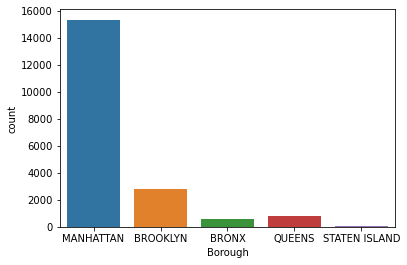

In [ ]:
x=(house_cost.Borough.value_counts())
p = sns.countplot(data=house_cost, x="Borough")
plt.show()

<Figure size 720x720 with 0 Axes>

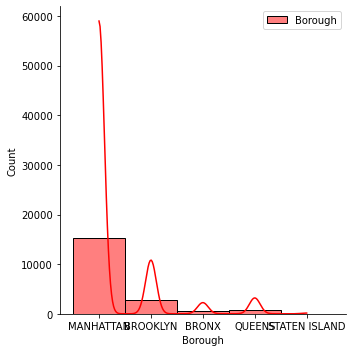

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(house_cost.Borough, color="red", label="Borough", kde= True)
plt.legend()

## Splitting the dataset into training and testing data

In [ ]:
x = df5.drop('Initial Cost',axis='columns')
x.head()

,Lot,Proposed Zoning Sqft,Enlargement SQ Footage,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
0,49,0,0,0,0,1,0,0
1,43,0,0,0,0,1,0,0
2,86,0,0,0,1,0,0,0
3,35,0,0,0,1,0,0,0
4,10,0,0,0,1,0,0,0


In [ ]:
y = df5['Initial Cost']
y.head()

0    0.208263
1    0.957702
2    0.020904
3    0.582983
4   -0.728536
Name: Initial Cost, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.2, random_state= 10)

In [ ]:
# Create an instance of StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data
scaler.fit(x_train)

# Transform the training and test data using the scaler
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Random Forest

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor()
rf.fit(x_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(x_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.9335670041224764


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Create and train the Random Forest regressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(x_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.0438606860368701


###  k-nearest neighbors (KNN)

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

knn = KNeighborsRegressor()
knn.fit(x_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(x_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.90627427517701


In [ ]:
# Create and train the KNN regressor
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(x_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.04872922217087694


### Support Vector Machines (SVM)

In [ ]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

svm = SVR()
svm.fit(x_train, y_train)

# Make predictions on the test set
y_pred = svm.predict(x_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.9588214113133132


In [ ]:
svm = SVR()
svm.fit(x_train, y_train)

# Make predictions on the test set
y_pred = svm.predict(x_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: -0.006426878398468672


### Decision Tree

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

# Make predictions on the test set
y_pred = dt.predict(x_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.1446794948618932


In [ ]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

# Make predictions on the test set
y_pred = dt.predict(x_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: -0.20097462525163912
